In [1]:
import pandas as pd
import numpy as np
import os

# This is the "df thing" but fixed to skip the NASA header
df = pd.read_csv("ethiopia.csv", skiprows=12)

# This handles the -999 values as required by Task 2
df.replace(-999, np.nan, inplace=True)
df.isna().sum()
# This shows you the data table
df.head()



,2015,12,14.27,21.59,9.19,12.4,0.04,73.51,2.96,4.32,77.12,9.15
0,2015,13,13.75,21.64,8.14,13.50,0.02,70.99,2.89,4.81,77.16,8.57
1,2015,14,13.81,23.98,5.38,18.60,0.00,58.83,2.35,3.73,77.16,6.63
2,2015,15,14.05,24.44,7.19,17.25,0.00,40.98,2.36,4.72,77.06,4.75
3,2015,16,13.73,23.81,5.57,18.24,0.00,50.50,2.07,3.12,77.06,5.73
4,2015,17,14.63,24.45,6.39,18.06,0.01,61.57,2.18,3.10,77.02,7.47


## Missing Values Analysis

Some columns contain missing values due to replacement of -999. Columns with higher missing values may affect the reliability of the analysis.

In [8]:
import pandas as pd
import numpy as np

# 1. Load without skipping since your file is already clean
df = pd.read_csv("ethiopia.csv")

# 2. Clean up any hidden spaces in the column names
# (Sometimes it's " YEAR" instead of "YEAR")
df.columns = df.columns.str.strip()

# 3. Handle NASA's -999 values
df.replace(-999, np.nan, inplace=True)
# Check for duplicates (KPI requirement)
print(f"Total duplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

# Missing value percentage report
missing_pct = (df.isna().sum() / len(df)) * 100
print("\nPercentage of missing values per column:")
print(missing_pct[missing_pct > 0]) # Only shows columns with missing data

# 4. Now try the date conversion again
df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df['Month'] = df['Date'].dt.month
df['Country'] = 'Ethiopia'

# 5. Check if it worked
print("Columns found:", df.columns.tolist())
df.head()

Total duplicate rows: 0

Percentage of missing values per column:
Series([], dtype: float64)
Columns found: ['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Date', 'Month', 'Country']


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,2015-01-01,1,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,2015-01-02,1,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,2015-01-03,1,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,2015-01-04,1,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,2015-01-05,1,Ethiopia


In [5]:
# 1. Add Country column
df['Country'] = 'Ethiopia'

# 2. Convert YEAR and DOY to a proper Date column
# This combines Year + Day of Year into a real calendar date
df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# 3. Extract Month for seasonal analysis
df['Month'] = df['Date'].dt.month

# 4. Handle Duplicates (KPI Requirement)
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")
df = df.drop_duplicates()

# 5. Missing Value Report (KPI Requirement)
missing_pct = (df.isna().sum() / len(df)) * 100
print("\nPercentage of missing values per column:")
print(missing_pct)

# Show the updated table with the new Date and Country columns
df.head()

Number of duplicate rows found: 0

Percentage of missing values per column:
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Date           0.0
Month          0.0
Country        0.0
dtype: float64


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,2015-01-01,1,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,2015-01-02,1,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,2015-01-03,1,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,2015-01-04,1,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,2015-01-05,1,Ethiopia


In [9]:
from scipy import stats

# Define columns from your instructions
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Calculate Z-scores (ignoring the NaNs we created with .replace)
z_scores = np.abs(stats.zscore(df[cols_to_check], nan_policy='omit'))

# Change .all(axis=1) to .any(axis=1)
outliers_mask = (z_scores > 3).any(axis=1)
print(f"Number of rows with extreme outliers: {outliers_mask.sum()}")

Number of rows with extreme outliers: 132


In [11]:
# 1. Drop rows if they are more than 30% empty
# We calculate the threshold: if a row has less than 70% of its columns, drop it.
limit = len(df.columns) * 0.7 
df = df.dropna(thresh=limit)

# 2. Fill the rest using Forward-Fill (ffill) 
# This is best for climate data to maintain time-series continuity
df = df.ffill()

print("Final missing value count:", df.isna().sum().sum())

Final missing value count: 0


In [12]:
import os
os.makedirs('data', exist_ok=True)
df.to_csv("data/ethiopia_clean.csv", index=False)
print("Success! Your cleaned data is saved.")

Success! Your cleaned data is saved.


In [14]:
import sys
!{sys.executable} -m pip install matplotlib seaborn scipy

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 1.8 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/8.2 MB 1.9 MB/s eta 0:00:04
   ----- ---------------------------------- 1.0/8.2 MB 1.7 MB/s eta 0:00:05
   ------ --------------------------------- 1.3/8.2 MB 1.5 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.2 MB 1.4 MB/s eta 0:00:05
   -------- ------------------------------- 1.8/8.2 MB 1.3 MB/s eta 0:00:06
   -------- ------------------------------- 1.8/8.2 MB 1.3 MB/s eta 0:00:06
   ---------- ----------------------------- 2.1/8.2 MB 1.2 MB/s eta 0:00:06
   ---------- ----------------------------- 2.1/8.2 MB 1.2 MB/s eta 0:00:06
   ----------- ---------------------------- 2.4/8.2 MB 1.1 MB/s eta 0:00:06
   ------------ --------

Matplotlib is building the font cache; this may take a moment.


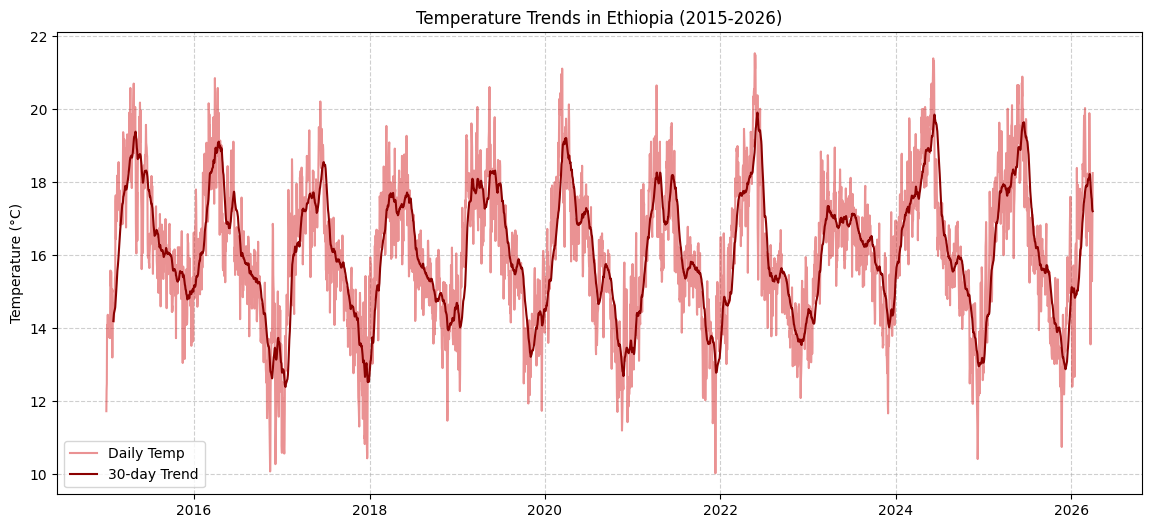

In [15]:
import matplotlib.pyplot as plt

# Group by the Date column you created earlier
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['T2M'], color='tab:red', alpha=0.5, label='Daily Temp')
# Adding a rolling mean to see the trend more clearly
plt.plot(df['Date'], df['T2M'].rolling(30).mean(), color='darkred', label='30-day Trend')

plt.title('Temperature Trends in Ethiopia (2015-2026)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

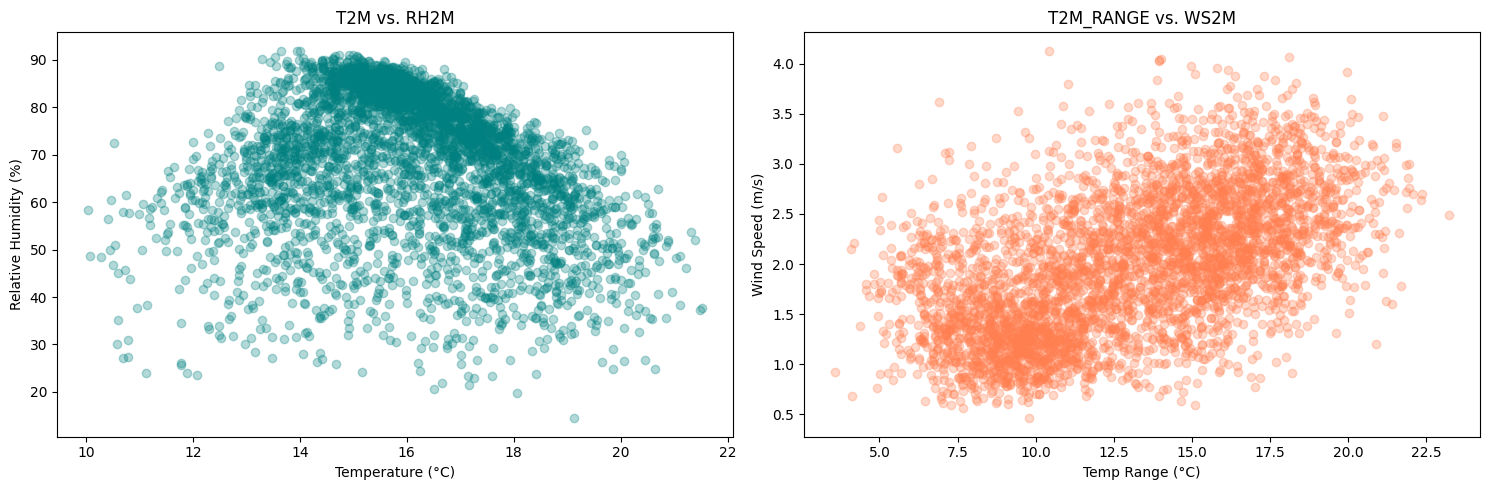

In [16]:
# Create a T2M_RANGE column first
df['T2M_RANGE'] = df['T2M_MAX'] - df['T2M_MIN']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Temperature vs Relative Humidity
ax1.scatter(df['T2M'], df['RH2M'], alpha=0.3, color='teal')
ax1.set_title('T2M vs. RH2M')
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Relative Humidity (%)')

# Plot 2: Temp Range vs Wind Speed
ax2.scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, color='coral')
ax2.set_title('T2M_RANGE vs. WS2M')
ax2.set_xlabel('Temp Range (°C)')
ax2.set_ylabel('Wind Speed (m/s)')

plt.tight_layout()
plt.show()

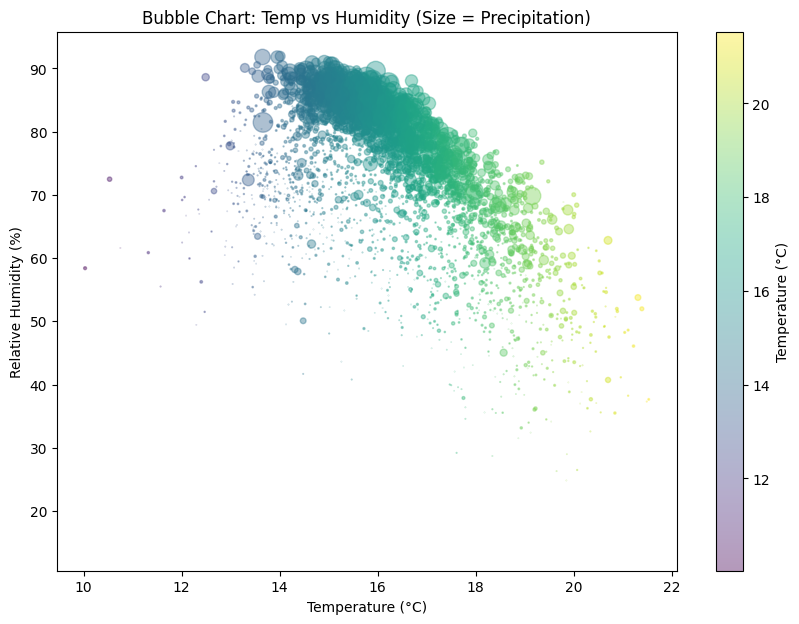

In [17]:
plt.figure(figsize=(10, 7))
# We use a subset or alpha because too many bubbles can overlap
plt.scatter(df['T2M'], df['RH2M'], 
            s=df['PRECTOTCORR'] * 5, # Multiply by 5 so bubbles are visible
            alpha=0.4, 
            c=df['T2M'], 
            cmap='viridis')

plt.colorbar(label='Temperature (°C)')
plt.title('Bubble Chart: Temp vs Humidity (Size = Precipitation)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.show()

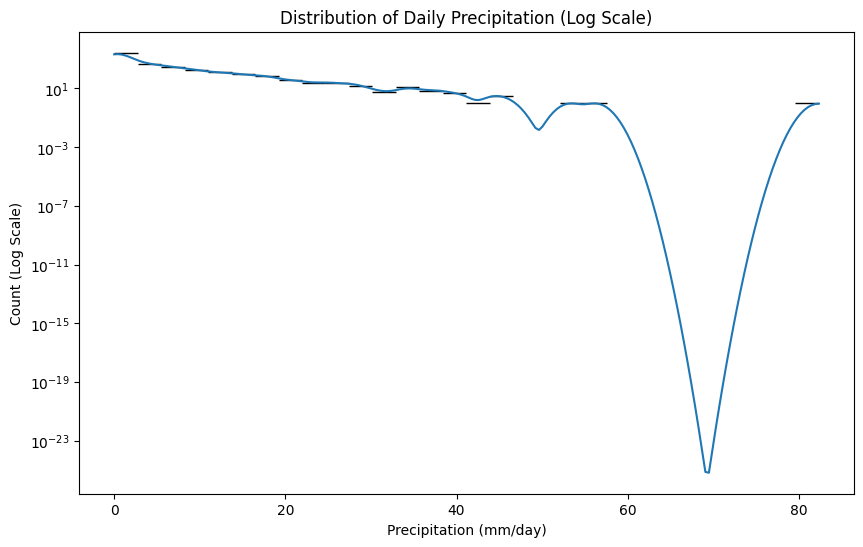

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Using a log scale because rainfall is usually heavily skewed towards zero
sns.histplot(df['PRECTOTCORR'], bins=30, kde=True, log_scale=(False, True))
plt.title('Distribution of Daily Precipitation (Log Scale)')
plt.xlabel('Precipitation (mm/day)')
plt.ylabel('Count (Log Scale)')
plt.show()


In [20]:
import os

# Create directory if it doesn't exist
if not os.path.exists('../data'):
    os.makedirs('../data')

# Export cleaned data
df.to_csv("../data/ethiopia_clean.csv", index=False)
print("Cleaned data saved to data/ethiopia_clean.csv")


Cleaned data saved to data/ethiopia_clean.csv
